# Задание

Описание/Пошаговая инструкция выполнения домашнего задания:

Мы можем использовать апостериорное прогнозируемое распределение для предсказания того, что произойдет, если мы снова подбросим ту же монету.


Используйте sample_posterior_predictive для генерации выборки k, а затем используйте sns.hist для построения графика апостериорного предсказательного распределения.

In [39]:
# Без этого не работает на Mac
import pytensor
pytensor.config.cxx = ""             # отключаем C++ компиляцию
pytensor.config.mode = "FAST_COMPILE"

In [40]:
import pymc as pm
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [70]:
# Давим лишний вывод
import logging

logging.getLogger("pymc").setLevel(logging.ERROR)
logging.getLogger("arviz").setLevel(logging.ERROR)

In [74]:
def try_pymc(n=100, p_true=0.5, k=10):
    '''
    Функция строит модель и выводит все нужные графики
    n - количество наблюдений
    p_true - истинная вероятность
    k - количество предсказаний
    '''
    
    # Генерируем данные
    rng = np.random.default_rng(42)  
    data = rng.binomial(n=1, p=p_true, size=n)
    
    # получаем апосториорносное распределение p
    with pm.Model() as model:
        # априорное распределение вероятности орла
        p = pm.Uniform("p", lower=0, upper=1)

        # наблюдения 
        y = pm.Bernoulli("y", p=p, observed=data)

        # сэмплируем апостериор p
        idata = pm.sample(
            draws=2000,
            tune=1000,
            random_seed=42,
            progressbar=False
            )
    
    # Визуализация p
    print(f"Среднее значение p = {idata.posterior["p"].mean():.3f}; Медиана p = {idata.posterior["p"].median():.3f}")
    
    sns.histplot(idata.posterior["p"].stack(sample=("chain", "draw")).values, bins=50)
    plt.title("Распределение p")
    plt.show()
    
    # Предсказываем 
    with model:
        y_new = pm.Bernoulli("y_new", p=p, shape=k)
        ppc = pm.sample_posterior_predictive(
            idata,
            var_names=["y_new"],
            random_seed=42,
            progressbar=False,
    )
        
    # Визуализируем количество орлов
    y_new_raw = ppc.posterior_predictive["y_new"]

    y_new_samps = y_new_raw.stack(sample=("chain", "draw")).values

    heads_counts = y_new_samps.sum(axis=0)   # axis=1, суммируем только по k

    sns.histplot(heads_counts, stat="probability", discrete=True)
    plt.xlabel(f"Число орлов в {k} новых бросках")
    plt.ylabel("Апостериорная вероятность")
    plt.title("Апостериорное предсказательное распределение")
    plt.show()
    

Среднее значение p = 0.471; Медиана p = 0.470


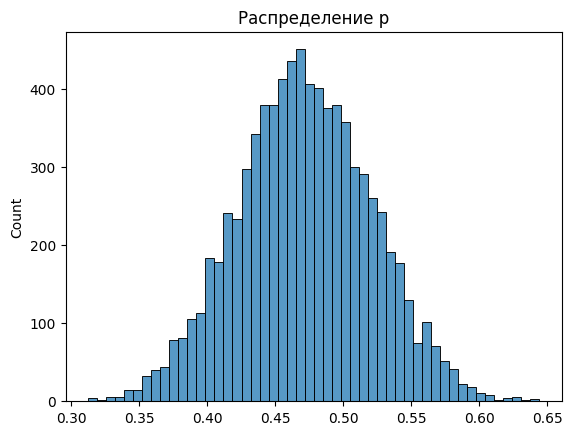

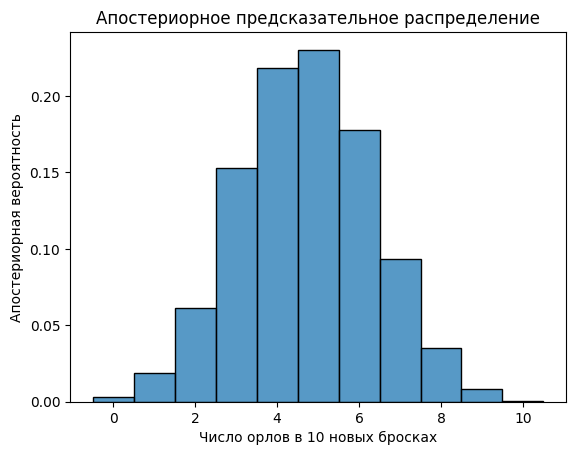

In [75]:
try_pymc(n=100)

Среднее значение p = 0.726; Медиана p = 0.728


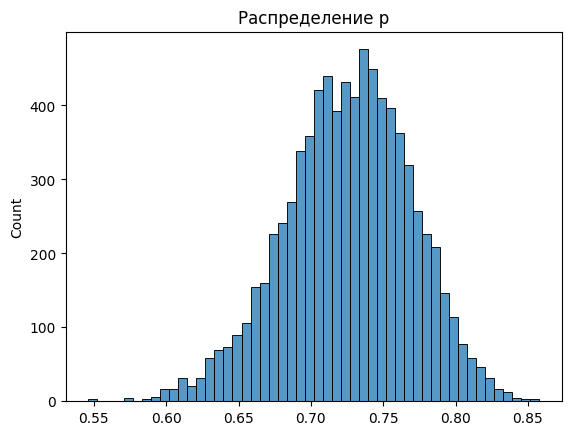

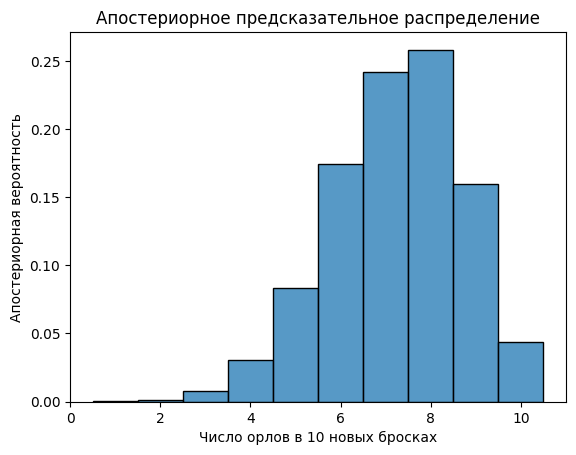

In [76]:
try_pymc(n=100, p_true=.7)

Среднее значение p = 0.696; Медиана p = 0.696


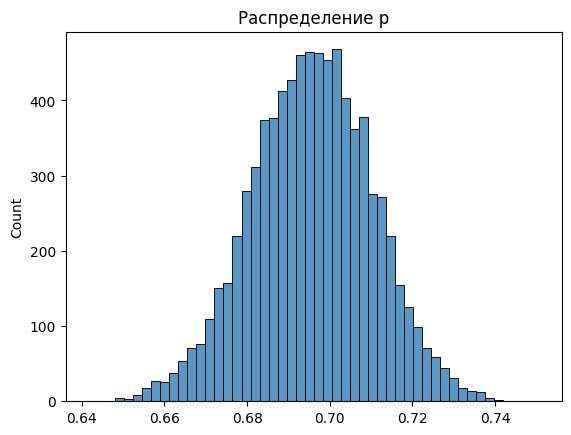

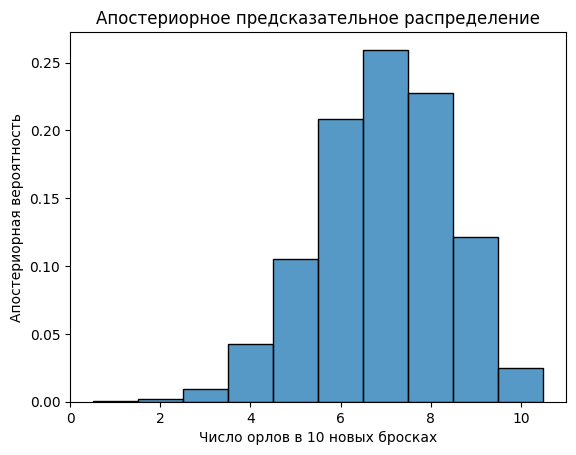

In [77]:
# Не удалось получить точное предсказание. Попробуем 1000 примеров
try_pymc(n=1000, p_true=0.7)